# Part 3: Deployment Layer — Version & Traffic Testing

## Objective
In this session, you will:
1. Serve two model versions (v1 baseline, v2 dropout-regularized)
2. Simulate random traffic routing (A/B canary deployment)
3. Log predictions and compare accuracy between versions
4. Measure latency and discuss throughput
5. Understand when to stop a canary and when to roll back

## Key Concepts
- **Canary Deployment**: Gradually rolling out new versions to a subset of traffic
- **A/B Testing**: Comparing two versions' performance on live traffic
- **Latency Monitoring**: Tracking inference speed across versions
- **Throughput**: How many requests the API can handle per second
- **Rate Limiting**: Protecting the API from overload

## Why Version & Traffic Testing?

A single model in isolation may perform well, but production ML involves:
- **Multiple versions**: Upgrades, rollbacks, experiments
- **Varying input patterns**: Real-world data isn't uniform
- **System load**: API must handle many concurrent requests
- **Monitoring**: Comparing versions and detecting degradation

**Version testing** ensures you can safely deploy model updates without breaking production.

---
## Step 1: Setup & Create Two Model Versions

In [1]:
import os
import io
import time
import random
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
from datetime import datetime
from collections import defaultdict

import torch
import torch.nn as nn
import torchvision.transforms as transforms
from torchvision.models import resnet18

from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.testclient import TestClient
from pydantic import BaseModel
import matplotlib.pyplot as plt

print("Libraries imported")

Libraries imported


In [2]:
# Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_names = ['animal', 'name_board', 'pedestrian', 'pothole', 'road_sign', 'speed_breaker', 'vehicle']
num_classes = len(class_names)

print(f"Device: {device}")
print(f"Classes: {class_names}")

Device: cpu
Classes: ['animal', 'name_board', 'pedestrian', 'pothole', 'road_sign', 'speed_breaker', 'vehicle']


---
## Step 2: Define Two Model Architectures

In [3]:
class BaselineModel(nn.Module):
    """Version 1: Basic ResNet-18 without regularization"""
    def __init__(self, num_classes):
        super().__init__()
        self.resnet = resnet18(weights=None)
        self.resnet.fc = nn.Linear(self.resnet.fc.in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)


class DropoutModel(nn.Module):
    """Version 2: ResNet-18 with Dropout for regularization"""
    def __init__(self, num_classes, dropout_rate=0.5):
        super().__init__()
        self.resnet = resnet18(weights=None)
        in_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.resnet(x)


# Create both models
model_v1 = BaselineModel(num_classes).to(device)
model_v2 = DropoutModel(num_classes).to(device)
model_v1.eval()
model_v2.eval()

print("Model V1 (Baseline) created")
print("Model V2 (Dropout) created")

Model V1 (Baseline) created
Model V2 (Dropout) created


In [4]:
# Image transformation
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transformation pipeline ready")

Transformation pipeline ready


---
## Step 3: Build Multi-Version API with Canary Routing

In [5]:
# Prediction logging
prediction_logs = []

class PredictionLog:
    """Store prediction metadata for analysis"""
    def __init__(self, timestamp, image_id, model_version, prediction, confidence, latency_ms):
        self.timestamp = timestamp
        self.image_id = image_id
        self.model_version = model_version
        self.prediction = prediction
        self.confidence = confidence
        self.latency_ms = latency_ms

    def to_dict(self):
        return {
            'timestamp': self.timestamp,
            'image_id': self.image_id,
            'model_version': self.model_version,
            'prediction': self.prediction,
            'confidence': self.confidence,
            'latency_ms': self.latency_ms
        }

print("Prediction logging system ready")

Prediction logging system ready


In [6]:
# API Schemas
class PredictionResponse(BaseModel):
    image_id: str
    prediction: str
    confidence: float
    model_version: str
    latency_ms: float

class ComparisonResponse(BaseModel):
    image_id: str
    v1_prediction: str
    v1_confidence: float
    v2_prediction: str
    v2_confidence: float
    agreement: bool
    v1_latency_ms: float
    v2_latency_ms: float

class MetricsResponse(BaseModel):
    total_requests: int
    v1_requests: int
    v2_requests: int
    avg_latency_ms: float
    agreement_rate: float

print("API response schemas defined")

API response schemas defined


c:\Users\Lucifer\anaconda3\envs\venv_ai_quality\lib\site-packages\pydantic\_internal\_fields.py:149: UserWarning: Field "model_version" has conflict with protected namespace "model_".

You may be able to resolve this warning by setting `model_config['protected_namespaces'] = ()`.
  warnings.warn(


In [7]:
# Create FastAPI app
app = FastAPI(
    title="ADAS Multi-Model API",
    description="Multi-version CNN serving with canary deployment and A/B testing",
    version="2.0"
)

# Traffic distribution: 30% to v2, 70% to v1
CANARY_PERCENTAGE = 30

print(f"FastAPI app created with {CANARY_PERCENTAGE}% canary traffic to v2")

FastAPI app created with 30% canary traffic to v2


In [8]:
@app.post("/predict")
async def predict_with_routing(file: UploadFile = File(...)):
    """
    Route prediction request to v1 or v2 based on canary percentage.
    """
    start_time = time.time()
    image_id = f"{datetime.now().timestamp()}"

    try:
        allowed_extensions = {'.jpg', '.jpeg', '.png', '.gif'}
        file_ext = Path(file.filename).suffix.lower()
        if file_ext not in allowed_extensions:
            raise HTTPException(status_code=400, detail=f"Invalid file type: {file_ext}")

        contents = await file.read()
        try:
            image = Image.open(io.BytesIO(contents)).convert('RGB')
        except Exception as e:
            raise HTTPException(status_code=400, detail=f"Could not open image: {str(e)}")

        # Random traffic split
        use_v2 = random.random() < (CANARY_PERCENTAGE / 100)
        model = model_v2 if use_v2 else model_v1
        model_version = "v2.0" if use_v2 else "v1.0"

        image_tensor = transform(image).unsqueeze(0).to(device)
        with torch.no_grad():
            outputs = model(image_tensor)
            probabilities = torch.softmax(outputs, dim=1)
            confidence, predicted_idx = torch.max(probabilities, 1)

        predicted_class = class_names[predicted_idx.item()]
        latency = (time.time() - start_time) * 1000

        log = PredictionLog(
            timestamp=datetime.now().isoformat(),
            image_id=image_id,
            model_version=model_version,
            prediction=predicted_class,
            confidence=round(confidence.item(), 4),
            latency_ms=round(latency, 2)
        )
        prediction_logs.append(log)

        return PredictionResponse(
            image_id=image_id,
            prediction=predicted_class,
            confidence=round(confidence.item(), 4),
            model_version=model_version,
            latency_ms=round(latency, 2)
        )

    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

print("/predict endpoint with canary routing defined")

/predict endpoint with canary routing defined


In [9]:
@app.post("/predict-both")
async def predict_both_models(file: UploadFile = File(...)):
    """
    Get predictions from BOTH models for A/B testing comparison.
    """
    image_id = f"{datetime.now().timestamp()}"

    try:
        allowed_extensions = {'.jpg', '.jpeg', '.png', '.gif'}
        file_ext = Path(file.filename).suffix.lower()
        if file_ext not in allowed_extensions:
            raise HTTPException(status_code=400, detail=f"Invalid file type: {file_ext}")

        contents = await file.read()
        try:
            image = Image.open(io.BytesIO(contents)).convert('RGB')
        except Exception as e:
            raise HTTPException(status_code=400, detail=f"Could not open image: {str(e)}")

        image_tensor = transform(image).unsqueeze(0).to(device)

        # V1 Prediction
        start_v1 = time.time()
        with torch.no_grad():
            outputs_v1 = model_v1(image_tensor)
            probs_v1 = torch.softmax(outputs_v1, dim=1)
            conf_v1, idx_v1 = torch.max(probs_v1, 1)
        latency_v1 = (time.time() - start_v1) * 1000

        # V2 Prediction
        start_v2 = time.time()
        with torch.no_grad():
            outputs_v2 = model_v2(image_tensor)
            probs_v2 = torch.softmax(outputs_v2, dim=1)
            conf_v2, idx_v2 = torch.max(probs_v2, 1)
        latency_v2 = (time.time() - start_v2) * 1000

        pred_v1 = class_names[idx_v1.item()]
        pred_v2 = class_names[idx_v2.item()]
        agreement = pred_v1 == pred_v2

        # Log both
        for mv, pred, conf, lat in [
            ("v1.0", pred_v1, conf_v1.item(), latency_v1),
            ("v2.0", pred_v2, conf_v2.item(), latency_v2)
        ]:
            prediction_logs.append(PredictionLog(
                timestamp=datetime.now().isoformat(),
                image_id=image_id,
                model_version=mv,
                prediction=pred,
                confidence=round(conf, 4),
                latency_ms=round(lat, 2)
            ))

        return ComparisonResponse(
            image_id=image_id,
            v1_prediction=pred_v1,
            v1_confidence=round(conf_v1.item(), 4),
            v2_prediction=pred_v2,
            v2_confidence=round(conf_v2.item(), 4),
            agreement=agreement,
            v1_latency_ms=round(latency_v1, 2),
            v2_latency_ms=round(latency_v2, 2)
        )

    except HTTPException:
        raise
    except Exception as e:
        raise HTTPException(status_code=500, detail=str(e))

print("/predict-both endpoint defined")

/predict-both endpoint defined


In [10]:
@app.get("/metrics")
async def get_metrics():
    """Get aggregated metrics from prediction logs."""
    if not prediction_logs:
        return MetricsResponse(
            total_requests=0, v1_requests=0, v2_requests=0,
            avg_latency_ms=0.0, agreement_rate=0.0
        )

    df = pd.DataFrame([log.to_dict() for log in prediction_logs])
    total_requests = len(df)
    v1_requests = len(df[df['model_version'] == 'v1.0'])
    v2_requests = len(df[df['model_version'] == 'v2.0'])
    avg_latency = df['latency_ms'].mean()

    # Agreement rate
    agreement_count = 0
    comparison_pairs = 0
    for image_id in df['image_id'].unique():
        logs_for_image = df[df['image_id'] == image_id]
        if len(logs_for_image) == 2:
            v1_logs = logs_for_image[logs_for_image['model_version'] == 'v1.0']
            v2_logs = logs_for_image[logs_for_image['model_version'] == 'v2.0']
            if not v1_logs.empty and not v2_logs.empty:
                if v1_logs.iloc[0]['prediction'] == v2_logs.iloc[0]['prediction']:
                    agreement_count += 1
                comparison_pairs += 1

    agreement_rate = (agreement_count / comparison_pairs * 100) if comparison_pairs > 0 else 0

    return MetricsResponse(
        total_requests=total_requests,
        v1_requests=v1_requests,
        v2_requests=v2_requests,
        avg_latency_ms=round(avg_latency, 2),
        agreement_rate=round(agreement_rate, 2)
    )


@app.get("/logs")
async def get_logs():
    """Get all prediction logs."""
    return {"total_logs": len(prediction_logs), "logs": [l.to_dict() for l in prediction_logs]}

print("/metrics and /logs endpoints defined")

/metrics and /logs endpoints defined


---
## Step 4: Test the Multi-Model API

In [11]:
client = TestClient(app)

def create_test_image(color='red'):
    """Create a dummy image for testing"""
    image = Image.new('RGB', (100, 100), color=color)
    img_bytes = io.BytesIO()
    image.save(img_bytes, format='PNG')
    img_bytes.seek(0)
    return img_bytes

print("TestClient ready")

TestClient ready


In [12]:
# TEST 1: Canary Routing — 100 requests, observe traffic split
print("\n" + "="*70)
print("TEST 1: Canary Deployment Routing (70% v1 / 30% v2)")
print("="*70)

prediction_logs.clear()  # Reset logs
version_counts = {"v1.0": 0, "v2.0": 0}

for i in range(100):
    img = create_test_image(color='red')
    response = client.post("/predict", files={"file": ("test.png", img, "image/png")})
    if response.status_code == 200:
        version_counts[response.json()["model_version"]] += 1

print(f"\nTraffic Distribution (100 requests):")
print(f"  V1: {version_counts['v1.0']} requests ({version_counts['v1.0']}%)")
print(f"  V2: {version_counts['v2.0']} requests ({version_counts['v2.0']}%)")
print(f"  Expected: ~70% v1, ~30% v2")


TEST 1: Canary Deployment Routing (70% v1 / 30% v2)

Traffic Distribution (100 requests):
  V1: 68 requests (68%)
  V2: 32 requests (32%)
  Expected: ~70% v1, ~30% v2


In [13]:
# TEST 2: A/B Testing — Compare both models on same images
print("\n" + "="*70)
print("TEST 2: A/B Testing - Compare Both Models")
print("="*70)

for i in range(5):
    img = create_test_image(color='blue')
    response = client.post("/predict-both", files={"file": ("test.png", img, "image/png")})
    if response.status_code == 200:
        result = response.json()
        agree = "AGREE" if result['agreement'] else "DISAGREE"
        print(f"\nComparison {i+1}:")
        print(f"  V1: {result['v1_prediction']} (conf={result['v1_confidence']:.4f}, {result['v1_latency_ms']:.2f}ms)")
        print(f"  V2: {result['v2_prediction']} (conf={result['v2_confidence']:.4f}, {result['v2_latency_ms']:.2f}ms)")
        print(f"  {agree}")


TEST 2: A/B Testing - Compare Both Models

Comparison 1:
  V1: road_sign (conf=0.5902, 55.18ms)
  V2: road_sign (conf=0.2522, 513.32ms)
  AGREE

Comparison 2:
  V1: road_sign (conf=0.5902, 95.69ms)
  V2: road_sign (conf=0.2522, 46.86ms)
  AGREE

Comparison 3:
  V1: road_sign (conf=0.5902, 36.08ms)
  V2: road_sign (conf=0.2522, 48.02ms)
  AGREE

Comparison 4:
  V1: road_sign (conf=0.5902, 57.04ms)
  V2: road_sign (conf=0.2522, 63.81ms)
  AGREE

Comparison 5:
  V1: road_sign (conf=0.5902, 45.42ms)
  V2: road_sign (conf=0.2522, 49.97ms)
  AGREE


In [14]:
# TEST 3: View Aggregated Metrics
print("\n" + "="*70)
print("TEST 3: Aggregated Metrics")
print("="*70)

response = client.get("/metrics")
if response.status_code == 200:
    metrics = response.json()
    print(f"Total Requests: {metrics['total_requests']}")
    if metrics['total_requests'] > 0:
        print(f"V1 Requests: {metrics['v1_requests']} ({metrics['v1_requests']/metrics['total_requests']*100:.1f}%)")
        print(f"V2 Requests: {metrics['v2_requests']} ({metrics['v2_requests']/metrics['total_requests']*100:.1f}%)")
    print(f"Average Latency: {metrics['avg_latency_ms']:.2f}ms")
    print(f"Model Agreement Rate: {metrics['agreement_rate']:.1f}%")


TEST 3: Aggregated Metrics
Total Requests: 110
V1 Requests: 73 (66.4%)
V2 Requests: 37 (33.6%)
Average Latency: 48.83ms
Model Agreement Rate: 100.0%


In [15]:
# TEST 4: Latency Comparison
print("\n" + "="*70)
print("TEST 4: Latency Comparison (v1 vs v2)")
print("="*70)

latencies_v1 = []
latencies_v2 = []

for i in range(20):
    img = create_test_image(color='green')
    response = client.post("/predict-both", files={"file": (f"bench_{i}.png", img, "image/png")})
    if response.status_code == 200:
        data = response.json()
        latencies_v1.append(data['v1_latency_ms'])
        latencies_v2.append(data['v2_latency_ms'])

print(f"\nV1 Latency: mean={np.mean(latencies_v1):.2f}ms, std={np.std(latencies_v1):.2f}ms")
print(f"V2 Latency: mean={np.mean(latencies_v2):.2f}ms, std={np.std(latencies_v2):.2f}ms")
print(f"Difference: {abs(np.mean(latencies_v1) - np.mean(latencies_v2)):.2f}ms")


TEST 4: Latency Comparison (v1 vs v2)

V1 Latency: mean=56.49ms, std=22.89ms
V2 Latency: mean=85.30ms, std=63.79ms
Difference: 28.81ms


---
## Step 5: Visualize Performance

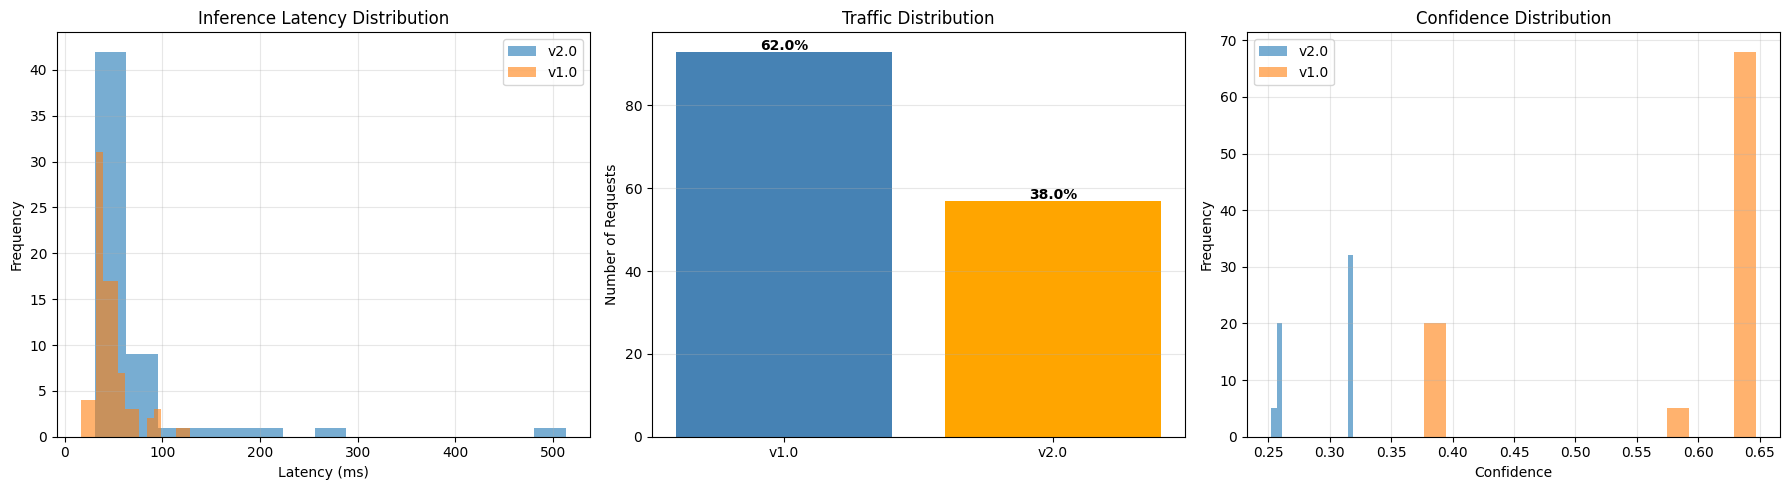

Analysis visualization saved


In [16]:
# Get all logs for analysis
response = client.get("/logs")
logs_data = response.json()['logs']
df = pd.DataFrame(logs_data)

if len(df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Latency distribution by version
    for version in df['model_version'].unique():
        version_latencies = df[df['model_version'] == version]['latency_ms']
        axes[0].hist(version_latencies, alpha=0.6, label=version, bins=15)
    axes[0].set_xlabel('Latency (ms)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Inference Latency Distribution')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Traffic distribution
    version_counts_df = df['model_version'].value_counts()
    axes[1].bar(version_counts_df.index, version_counts_df.values, color=['steelblue', 'orange'])
    axes[1].set_ylabel('Number of Requests')
    axes[1].set_title('Traffic Distribution')
    for i, v in enumerate(version_counts_df.values):
        pct = v / version_counts_df.sum() * 100
        axes[1].text(i, v + 0.5, f'{pct:.1f}%', ha='center', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')

    # Confidence distribution by version
    for version in df['model_version'].unique():
        confs = df[df['model_version'] == version]['confidence']
        axes[2].hist(confs, alpha=0.6, label=version, bins=15)
    axes[2].set_xlabel('Confidence')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title('Confidence Distribution')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('deployment_testing_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Analysis visualization saved")
else:
    print("No logs to analyze")

---
## Step 6: Report & Discussion

In [17]:
if len(df) > 0:
    v1_latency = df[df['model_version'] == 'v1.0']['latency_ms'].mean()
    v2_latency = df[df['model_version'] == 'v2.0']['latency_ms'].mean()

    print("=" * 70)
    print("DEPLOYMENT TESTING REPORT")
    print("=" * 70)

    print(f"""
CANARY DEPLOYMENT:
  - {CANARY_PERCENTAGE}% of traffic routed to v2
  - Main traffic continues with stable v1
  - If v2 shows issues, rollback affects only {CANARY_PERCENTAGE}% of users

LATENCY COMPARISON:
  - V1 Average: {v1_latency:.2f}ms
  - V2 Average: {v2_latency:.2f}ms
  - Difference: {abs(v1_latency - v2_latency):.2f}ms

THROUGHPUT:
  - Total Requests Processed: {len(df)}

RATE LIMITING:
  - Protects API from overload (e.g., 5 req/60s per client)
  - Prevents DDoS and abuse
  - Returns HTTP 429 when limit exceeded

WHEN TO STOP A CANARY:
  - Agreement rate < 70% between v1 and v2
  - v2 latency > 2x v1 latency
  - v2 error rate > 5%
  - Confidence scores significantly lower on v2

WHEN TO ROLL BACK:
  - Accuracy drops below production threshold
  - Error rate spikes suddenly
  - Latency exceeds SLA
  - User-reported issues increase
""")

    print("=" * 70)

DEPLOYMENT TESTING REPORT

CANARY DEPLOYMENT:
  - 30% of traffic routed to v2
  - Main traffic continues with stable v1
  - If v2 shows issues, rollback affects only 30% of users

LATENCY COMPARISON:
  - V1 Average: 46.98ms
  - V2 Average: 67.32ms
  - Difference: 20.34ms

THROUGHPUT:
  - Total Requests Processed: 150

RATE LIMITING:
  - Protects API from overload (e.g., 5 req/60s per client)
  - Prevents DDoS and abuse
  - Returns HTTP 429 when limit exceeded

WHEN TO STOP A CANARY:
  - Agreement rate < 70% between v1 and v2
  - v2 latency > 2x v1 latency
  - v2 error rate > 5%
  - Confidence scores significantly lower on v2

WHEN TO ROLL BACK:
  - Accuracy drops below production threshold
  - Error rate spikes suddenly
  - Latency exceeds SLA
  - User-reported issues increase



In [18]:
print("""
DEPLOYMENT STRATEGIES

1. BLUE-GREEN DEPLOYMENT:
   Blue (v1) = Production | Green (v2) = Staging
   When v2 ready -> switch ALL traffic instantly
   If issues -> switch back immediately
   Zero downtime, instant rollback

2. CANARY DEPLOYMENT (our approach):
   10% -> 25% -> 50% -> 100%
   Gradually increase v2 traffic
   Monitor metrics at each stage
   Stop if degradation detected

3. SHADOW DEPLOYMENT:
   v2 processes in background (no user impact)
   Compare predictions offline
   Validate before any real traffic

4. A/B TESTING:
   Different versions to different user cohorts
   Statistical significance testing
   Winner deployed to all
""")


DEPLOYMENT STRATEGIES

1. BLUE-GREEN DEPLOYMENT:
   Blue (v1) = Production | Green (v2) = Staging
   When v2 ready -> switch ALL traffic instantly
   If issues -> switch back immediately
   Zero downtime, instant rollback

2. CANARY DEPLOYMENT (our approach):
   10% -> 25% -> 50% -> 100%
   Gradually increase v2 traffic
   Monitor metrics at each stage
   Stop if degradation detected

3. SHADOW DEPLOYMENT:
   v2 processes in background (no user impact)
   Compare predictions offline
   Validate before any real traffic

4. A/B TESTING:
   Different versions to different user cohorts
   Statistical significance testing
   Winner deployed to all



---
## Key Takeaways

1. **Canary deployments reduce risk**: Test v2 with a small % of traffic before full rollout.

2. **A/B testing provides data-driven model selection**: Compare versions on the same inputs to measure real differences.

3. **Latency monitoring catches performance regressions**: Track inference speed per version — a dropout layer shouldn't add >10% latency.

4. **Rate limiting protects production**: Prevent abuse and overload with per-client request limits.

5. **Agreement rates indicate stability**: If v1 and v2 agree >90%, the new model is likely safe. Below 70% — investigate.

6. **Comprehensive logging enables root cause analysis**: Log every prediction with version, confidence, and latency for post-hoc analysis.

### Running the Standalone API
```bash
# Start the multi-model API
uvicorn api_multimodel:app --reload --port 8000

# Start Streamlit dashboard
streamlit run streamlit_app.py

# Run tests
pytest test_part3.py -v
```